/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/scripts
/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency
482 419


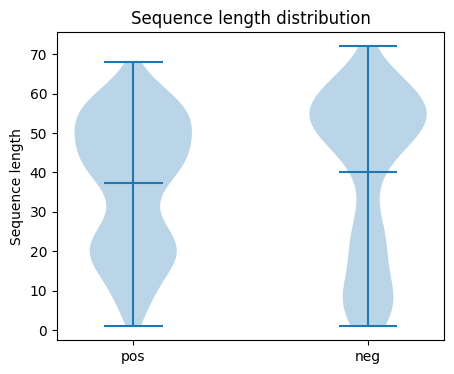

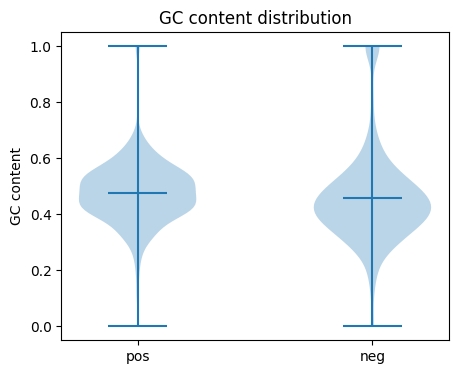

GC content: n_pos=482, n_neg=419, mean_pos=0.476, mean_neg=0.458, median_pos=0.475, median_neg=0.435


NameError: name 'mannwhitneyu' is not defined

In [1]:
import pickle
import os
import numpy as np
from matplotlib import pyplot as plt
 
try:
    os.chdir('scripts')
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances = pickle.load(f)
except:
    os.chdir('../../scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances = pickle.load(f)
 
importances_train = pickle.load(open("output/importance/train_shap.pkl", "rb"))
importances_test = pickle.load(open("output/importance/test_shap.pkl", "rb"))
 
allPosSeqs = []
allNegSeqs = []
for imps in [importances, importances_train, importances_test]:
    posSeqs = []
    negSeqs = []
    for imp in imps:
        ind = min(imp.tokens.index('[SEP]'), 10)
        if ind > 0:
            seq = ''
            i = 1
            if imp.scores[1] > 0:
                while i <= ind:
                    if imp.scores[i] > 0:
                        seq += imp.tokens[i]
                        i += 1
                    else:
                        break
                if seq:
                    posSeqs.append(seq)
            else:
                while i <= ind:
                    if imp.scores[i] < 0:
                        seq += imp.tokens[i]
                        i += 1
                    else:
                        break
                if seq:
                    negSeqs.append(seq)
    print(len(posSeqs), len(negSeqs))
    allPosSeqs.append(posSeqs)
    allNegSeqs.append(negSeqs)
 
    # Plot distribution of sequence lengths for posSeqs and negSeqs
    pos_len = [len(s) for s in posSeqs]
    neg_len = [len(s) for s in negSeqs]
 
    fig_len, ax_len = plt.subplots(figsize=(5,4))
    ax_len.violinplot([pos_len, neg_len], showmeans=True)
    ax_len.set_xticks([1, 2])
    ax_len.set_xticklabels(['pos', 'neg'])
    ax_len.set_ylabel('Sequence length')
    ax_len.set_title('Sequence length distribution')
    plt.show()
    # Compute GC content and AU dinucleotide frequency for posSeqs and negSeqs and plot violins.
 
    def _clean(seq):
        return ''.join([b for b in seq.upper() if b in ('A','C','G','T')])
 
    def gc_content(seq):
        s = _clean(seq)
        if not s:
            return 0.0
        gc = s.count('G') + s.count('C')
        return gc / len(s)
 
    pos_gc = [gc_content(s) for s in posSeqs]
    neg_gc = [gc_content(s) for s in negSeqs]
 
    # GC content violin plot
    fig_gc, ax_gc = plt.subplots(figsize=(5,4))
    gc_parts = ax_gc.violinplot([pos_gc, neg_gc], showmeans=True)
    ax_gc.set_xticks([1,2])
    ax_gc.set_xticklabels(['pos','neg'])
    ax_gc.set_ylabel('GC content')
    ax_gc.set_title('GC content distribution')
    plt.show()
    def summarize_and_test(x, y, name):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        print(f"{name}: n_pos={len(x)}, n_neg={len(y)}, "
              f"mean_pos={x.mean():.3f}, mean_neg={y.mean():.3f}, "
              f"median_pos={np.median(x):.3f}, median_neg={np.median(y):.3f}")
        u_stat, u_p = mannwhitneyu(x, y, alternative='two-sided')
        ks_stat, ks_p = ks_2samp(x, y, alternative='two-sided', mode='auto')
        t_stat, t_p = ttest_ind(x, y, equal_var=False)
        print(f"  Mann–Whitney U: U={u_stat:.1f}, p={u_p:.3e}")
        print(f"  KS test: D={ks_stat:.3f}, p={ks_p:.3e}")
        print(f"  Welch's t-test: t={t_stat:.3f}, p={t_p:.3e}")
 
    summarize_and_test(pos_gc, neg_gc, "GC content")
 
    def au_dinuc_freq(seq,dinuc):
        # Treat T as U for AU counting
        s = _clean(seq).replace('T', 'U')
        if len(s) < 2:
            return 0.0
        count = sum(1 for i in range(len(s)-1) if s[i:i+2] == dinuc) #in ['UA',])#'AU','AA','UU'])
        return count / (len(s) - 1)
 
    for dinuc in ['AA', 'UU', 'UA', 'AU']:
        pos_au = [au_dinuc_freq(s,dinuc) for s in posSeqs]
        neg_au = [au_dinuc_freq(s,dinuc) for s in negSeqs]
        # AU dinucleotide frequency violin plot
        fig_au, ax_au = plt.subplots(figsize=(5,4))
        au_parts = ax_au.violinplot([pos_au, neg_au], showmeans=True)
        ax_au.set_xticks([1,2])
        ax_au.set_xticklabels(['pos','neg'])
        ax_au.set_ylabel(f'{dinuc} dinucleotide frequency')
        ax_au.set_title(f'{dinuc} dinucleotide frequency distribution')
        plt.show()
        from scipy.stats import mannwhitneyu, ks_2samp, ttest_ind
 
        summarize_and_test(pos_au, neg_au, f"{dinuc} dinucleotide freq")
 
    def aug_trinuc_freq(seq):
        # Treat T as U for AUG counting
        s = _clean(seq).replace('T', 'U')
        if len(s) < 3:
            return 0.0
        count = sum(1 for i in range(len(s)-2) if s[i:i+3] == 'AUG')
        return count / (len(s) - 2)
    pos_aug = [aug_trinuc_freq(s) for s in posSeqs]
    neg_aug = [aug_trinuc_freq(s) for s in negSeqs]
    # AUG trinucleotide frequency violin plot
    fig_aug, ax_aug = plt.subplots(figsize=(5,4))
    aug_parts = ax_aug.violinplot([pos_aug, neg_aug], showmeans=True)
    ax_aug.set_xticks([1,2])
    ax_aug.set_xticklabels(['pos','neg'])
    ax_aug.set_ylabel('AUG trinucleotide frequency')
    ax_aug.set_title('AUG trinucleotide frequency distribution')
    plt.show()
 
    summarize_and_test(pos_aug, neg_aug, "AUG trinucleotide frequency")

In [ ]:
impDict = {imp.id: imp for imp in importances}

In [ ]:
# Read the file, skipping the first two lines that start with #
import pandas as pd
import os
from Bio import SeqIO
 
try:
    df = pd.read_csv('output/mast_out/dev_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python')
except:
    os.chdir('../..')
    df = pd.read_csv('output/mast_out/dev_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python')
df.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']
 
motifPos = pd.read_csv('output/motifs/dev/positive/motif_positions.txt', sep='\t')
motifNeg = pd.read_csv('output/motifs/dev/negative/motif_positions.txt', sep='\t')
 
from Bio import SeqIO
import numpy as np
 
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
 
def draw_sequence(ax, seq, y=0.007, fontsize=8):
    for i, ch in enumerate(seq):
        ax.text(i, y, ch, fontproperties='monospace', fontsize=fontsize, ha='center', va='center')
 
def span_from_1based(start, end):
    # convert 1-based inclusive [start,end] to 0-based start and width in bases
    start0 = int(start) - 1
    width = int(end) - int(start) + 1
    return start0, width
#matplotlib.use('Agg')  # Use same backend for both display and save
#plt.rcParams['figure.dpi'] = 300  # Set consistent DPI
 
def filter_rbp_hits(pMotifs, nMotifs, rbp5, rbp3):
    mergedMotifs = pd.concat([pMotifs, nMotifs], ignore_index=True)
    filt5 = pd.DataFrame(columns=rbp5.columns)
    filt3 = pd.DataFrame(columns=rbp3.columns)
    for _, motif in mergedMotifs.iterrows():
        if motif['start'] <= motif['sepStart']:  # 5' UTR region
            if motif['trID']+'_5utr' in rbp5['sequence_name'].values:
                tmp = rbp5[rbp5['sequence_name'] == motif['trID']+'_5utr']
                for t in tmp.iterrows():
                    if (t[1]['hit_start'] >= motif['start'] and t[1]['hit_start'] <= motif['end']) or (t[1]['hit_end'] > motif['start'] and t[1]['hit_end'] <= motif['end']):
                        filt5 = pd.concat([filt5, pd.DataFrame([t[1]])], ignore_index=True)
        else:  # 3' UTR region
            if motif['trID']+'_3utr' in rbp3['sequence_name'].values:
                tmp = rbp3[rbp3['sequence_name'] == motif['trID']+'_3utr']
                for t in tmp.iterrows():
                    if (t[1]['hit_start'] >= (motif['start'] - motif['sepEnd']) and t[1]['hit_start'] <= (motif['end'] - motif['sepEnd'])) or (t[1]['hit_end'] > (motif['start'] - motif['sepEnd']) and t[1]['hit_end'] <= (motif['end'] - motif['sepEnd'])):
                        filt3 = pd.concat([filt3, pd.DataFrame([t[1]])], ignore_index=True)
    return filt5, filt3
 
def getHitList(file_path):
    df = pd.read_csv(file_path, index_col=0)
    hit_list = df[(df['p_adj'] < 0.05) & (df['motif_mean'] > df['control_mean'])].index.tolist()
    return hit_list
 
pos5_motifs = getHitList('output/motifEnrichment/train_pos5_mannwhitneyu_results.csv')
pos3_motifs = getHitList('output/motifEnrichment/train_pos3_mannwhitneyu_results.csv')
neg5_motifs = getHitList('output/motifEnrichment/train_neg5_mannwhitneyu_results.csv')
neg3_motifs = getHitList('output/motifEnrichment/train_neg3_mannwhitneyu_results.csv')
 
# Find the sequence for FBtr0073819
# Read the FASTA file once and store sequences in a dictionary
seq_dict = {}
with open('output/data/decay/dev.fasta', 'r') as fasta_file:
    for seq_record in SeqIO.parse(fasta_file, 'fasta'):
        tr_id = seq_record.description.split()[1]
        seq_dict[tr_id] = str(seq_record.seq)
 
posRBPs = {}
negRBPs = {}
for target_trID in impDict.keys(): #visualizeList: #['FBtr0073819','FBtr0071189','FBtr0071221']:
    target_seq = seq_dict.get(target_trID, None)
    
    if target_seq is None:
        print(f"Sequence {target_trID} not found in dev.fasta")
    else:
        # Split into 5' and 3' UTRs based on comma
        comma_pos = min(70,target_seq.index(','))
        utr5_seq = target_seq[:comma_pos]
        if len(utr5_seq) <= 1:
            continue
        utr3_seq = ''#target_seq[comma_pos+1:]
        
        
        # Get positive motif positions for this trID
        pos_motifs = motifPos[motifPos['trID'] == target_trID]
        
        # Get negative motif positions for this trID
        neg_motifs = motifNeg[motifNeg['trID'] == target_trID]
        
        # Get RBP motif hits from df for this trID
        rbp_hits_5utr = df[df['sequence_name'] == f'{target_trID}_5utr']
        rbp_hits_3utr = df[df['sequence_name'] == f'{target_trID}_3utr']
        # Filter RBP hits to only those overlapping with positive/negative motifs
        #rbp_hits_5utr, rbp_hits_3utr = filter_rbp_hits(pos_motifs, neg_motifs, rbp_hits_5utr, rbp_hits_3utr)
        
        # Create the visualization
        xmax = max(len(utr5_seq), len(utr3_seq))  # Extend x-axis to accommodate motifs
        fig, (ax1) = plt.subplots(1, 1, figsize=(0.0769*xmax, 1.5))
        rectHeight = 0.03
        rectY_SHAP = -0.005
        alphaSHAP = 0.3
        rectY_Motif = 0.03
        ymin = -0.1
        ymax = 0.1
        xminMod = 0#-1
        xmaxMod = 0#31
        rbpHeight = 0.02
        rbpLabelHeight = 0.05
        widthMod = 0.4
        motifStartMod = 0.4
        
        # Plot 5' UTR
        #ax1.text(0, 0, utr5_seq, fontfamily='monospace', fontsize=8)
        draw_sequence(ax1, utr5_seq, fontsize=8)
        ax1.set_xlim(xminMod, xmax + xmaxMod)
        ax1.set_ylim(ymin, ymax)
        ax1.set_title(f"{target_trID} - 5' UTR (length: {len(utr5_seq)})")
        ax1.yaxis.set_visible(False)  # Hide y-axis for better visualization
        ax1.axis('off')
    
    
        # Add positive motif boxes for 5' UTR
        for _, motif in pos_motifs.iterrows():
            if motif['start'] <= comma_pos:#motif['sepStart']:  # 5' UTR region
                start_pos = motif['start'] - motifStartMod
                end_pos = motif['end']
                width = end_pos - start_pos + widthMod
                rect = patches.Rectangle((start_pos, rectY_SHAP), width, rectHeight,
                                       linewidth=1, edgecolor='red', facecolor='red', alpha=alphaSHAP)
                ax1.add_patch(rect)
                #ax1.axvspan(start_pos, end_pos, color='red', alpha=0.5)
        
        # Add negative motif boxes for 5' UTR
        for _, motif in neg_motifs.iterrows():
            if motif['start'] <= comma_pos: #motif['sepStart']:  # 5' UTR region
                start_pos = motif['start'] - motifStartMod
                end_pos = motif['end']
                width = end_pos - start_pos + widthMod
                rect = patches.Rectangle((start_pos, rectY_SHAP), width, rectHeight,
                                       linewidth=1, edgecolor='blue', facecolor='blue', alpha=alphaSHAP)
                ax1.add_patch(rect)
                #ax1.axvspan(start_pos, end_pos, color='blue', alpha=0.5)
        
        # Add RBP motif labels above 5' UTR sequence
        for _, rbp in rbp_hits_5utr.iterrows():
            color = 'red' if rbp['alt_id'] in pos5_motifs else 'blue' if rbp['alt_id'] in neg5_motifs else '#d66d6d' if rbp['alt_id'] in pos3_motifs else '#6d6dd6' if rbp['alt_id'] in neg3_motifs else 'black'
            mid_pos = (rbp['hit_start']-1.4-motifStartMod + rbp['hit_end']) / 2
            if rbp['hit_start'] < comma_pos:
                ax1.text(mid_pos, rbpLabelHeight, rbp['alt_id'], ha='center', va='bottom',
                    fontsize=7.5, color=color)#, rotation=45)
                if impDict[target_trID].scores[1] > 0:
                    if rbp['alt_id'] not in posRBPs:
                        posRBPs[rbp['alt_id']] = 1
                    else:
                        posRBPs[rbp['alt_id']] += 1
                else:
                    if rbp['alt_id'] not in negRBPs:
                        negRBPs[rbp['alt_id']] = 1
                    else:
                        negRBPs[rbp['alt_id']] += 1
        
    
        # Add RBP motif spans
        for _, rbp in rbp_hits_5utr.iterrows():
            color = 'red' if rbp['alt_id'] in pos5_motifs else 'blue' if rbp['alt_id'] in neg5_motifs else '#d66d6d' if rbp['alt_id'] in pos3_motifs else '#6d6dd6' if rbp['alt_id'] in neg3_motifs else 'gray'
            #ax1.axvspan(rbp['hit_start']-1, rbp['hit_end']-0.25, color=color, alpha=0.2, linewidth=0)
            if rbp['hit_start'] < comma_pos:
                ax1.add_patch(patches.Rectangle((rbp['hit_start']-1-motifStartMod, rectY_Motif), rbp['hit_end']-rbp['hit_start']+0.75, rbpHeight,
                                       linewidth=1, edgecolor=color, facecolor=color, alpha=0.5))
    
        
        plt.tight_layout()
        plt.savefig(f'figures/{target_trID}_motif_visualization.svg', dpi=300)
        plt.show()
 

In [ ]:
for k in set(list(posRBPs.keys())).union(set(negRBPs.keys())):
    print(f"{k}, count: {posRBPs.get(k, 0)/482*100:.2f}%, {negRBPs.get(k, 0)/419*100:.2f}%")

In [ ]:
nucFreq = {'A': 0, 'T': 0, 'C': 0, 'G': 0}
for s in allPosSeqs[0]:
    nucFreq[s[0]] += 1
print(nucFreq)
nucFreq = {'A': 0, 'T': 0, 'C': 0, 'G': 0}
for s in allNegSeqs[0]:
    if s[0] != '[':
        nucFreq[s[0]] += 1
nucFreq

In [ ]:
import matplotlib.pyplot as plt
 
# Collect data for positive sequences
pos_data = {}
for i, id_ in enumerate(allPosSeqs_ids[0]):
    seq = allPosSeqs[0][i]
    first_char = seq[0] if seq else 'N'
    actual = impDict[id_].prediction
    if first_char not in pos_data:
        pos_data[first_char] = []
    pos_data[first_char].append(actual)
 
# Collect data for negative sequences
neg_data = {}
for i, id_ in enumerate(allNegSeqs_ids[0]):
    seq = allNegSeqs[0][i]
    first_char = seq[0] if seq else 'N'
    actual = impDict[id_].prediction
    if first_char not in neg_data:
        neg_data[first_char] = []
    neg_data[first_char].append(actual)
 
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
# Positive sequences violin plot
if pos_data:
    sorted_keys_pos = sorted(pos_data.keys())
    data_pos = [pos_data[key] for key in sorted_keys_pos]
    ax1.violinplot(data_pos, showmeans=True)
    ax1.set_xticks(range(1, len(sorted_keys_pos) + 1))
    ax1.set_xticklabels(sorted_keys_pos)
    ax1.set_ylabel('imp.prediction')
    ax1.set_title('Positive sequences: imp.prediction by first character')
 
# Negative sequences violin plot
if neg_data:
    sorted_keys_neg = sorted(neg_data.keys())
    data_neg = [neg_data[key] for key in sorted_keys_neg]
    ax2.violinplot(data_neg, showmeans=True)
    ax2.set_xticks(range(1, len(sorted_keys_neg) + 1))
    ax2.set_xticklabels(sorted_keys_neg)
    ax2.set_ylabel('imp.prediction')
    ax2.set_title('Negative sequences: imp.prediction by first character')
 
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
 
# Collect data for positive sequences
pos_data = {}
for i, id_ in enumerate(allPosSeqs_ids[0]):
    seq = allPosSeqs[0][i]
    first_char = seq[0] if seq else 'N'
    actual = impDict[id_].prediction
    if first_char not in pos_data:
        pos_data[first_char] = []
    pos_data[first_char].append(actual)
 
# Collect data for negative sequences
neg_data = {}
for i, id_ in enumerate(allNegSeqs_ids[0]):
    seq = allNegSeqs[0][i]
    first_char = seq[0] if seq else 'N'
    actual = impDict[id_].prediction
    if first_char not in neg_data:
        neg_data[first_char] = []
    neg_data[first_char].append(actual)
 
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
# Positive sequences violin plot
if pos_data:
    sorted_keys_pos = sorted(pos_data.keys())
    data_pos = [pos_data[key] for key in sorted_keys_pos]
    ax1.violinplot(data_pos, showmeans=True)
    ax1.set_xticks(range(1, len(sorted_keys_pos) + 1))
    ax1.set_xticklabels(sorted_keys_pos)
    ax1.set_ylabel('imp.prediction')
    ax1.set_title('Positive sequences: imp.prediction by first character')
 
# Negative sequences violin plot
if neg_data:
    sorted_keys_neg = sorted(neg_data.keys())
    data_neg = [neg_data[key] for key in sorted_keys_neg]
    ax2.violinplot(data_neg, showmeans=True)
    ax2.set_xticks(range(1, len(sorted_keys_neg) + 1))
    ax2.set_xticklabels(sorted_keys_neg)
    ax2.set_ylabel('imp.prediction')
    ax2.set_title('Negative sequences: imp.prediction by first character')
 
plt.tight_layout()
plt.show()